#### Analiza danych

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Wczytanie danych

In [ ]:
dtype_dict = {
    'Store': int,
    'DayOfWeek': int,
    'Date': object,
    'Sales': int,
    'Customers': int,
    'Open': bytes,
    'Promo': bytes,
    'StateHoliday': str,
    'SchoolHoliday': int
}

df_store = pd.read_csv("../data/raw/store.csv")
df_train = pd.read_csv("../data/raw/train.csv", dtype = dtype_dict)

2. Informacje o danych

+ Podgląd danych

In [2]:
df_store

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


+ Łączenie danych

In [ ]:
df_m = df_train.merge(df_store, on='Store', how='left')
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


+ info

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  object 
 6   Promo                      1017209 non-null  object 
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [5]:
df.describe().applymap(lambda x: f"{x:.2f}")


/tmp/ipykernel_66153/2352367069.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.describe().applymap(lambda x: f"{x:.2f}")


,Store,DayOfWeek,Sales,Customers,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00,1014567.00,693861.00,693861.00,1017209.00,509178.00,509178.00
mean,558.43,4.00,5773.82,633.15,0.18,5430.09,7.22,2008.69,0.50,23.27,2011.75
std,321.91,2.00,3849.93,464.41,0.38,7715.32,3.21,5.99,0.50,14.10,1.66
min,1.00,1.00,0.00,0.00,0.00,20.00,1.00,1900.00,0.00,1.00,2009.00
25%,280.00,2.00,3727.00,405.00,0.00,710.00,4.00,2006.00,0.00,13.00,2011.00
50%,558.00,4.00,5744.00,609.00,0.00,2330.00,8.00,2010.00,1.00,22.00,2012.00
75%,838.00,6.00,7856.00,837.00,0.00,6890.00,10.00,2013.00,1.00,37.00,2013.00
max,1115.00,7.00,41551.00,7388.00,1.00,75860.00,12.00,2015.00,1.00,50.00,2015.00


In [6]:
df["PromoInterval"].unique()

array([nan, 'Jan,Apr,Jul,Oct', 'Feb,May,Aug,Nov', 'Mar,Jun,Sept,Dec'],
      dtype=object)

In [7]:
df[df["CompetitionOpenSinceMonth"].isna()]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,5,2015-07-31,8959,962,1,1,0,1,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,5,2015-07-31,8821,568,1,1,0,0,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,5,2015-07-31,10231,979,1,1,0,1,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,5,2015-07-31,8234,718,1,1,0,1,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,5,2015-07-31,6566,633,1,1,0,0,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017189,1096,2,2013-01-01,0,0,0,0,a,1,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1017193,1100,2,2013-01-01,0,0,0,0,a,1,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


+ Kodowanie

In [34]:
df_new = pd.get_dummies(df, columns=["Assortment"], prefix="assortment")
df_new = pd.get_dummies(df_new, columns=["StoreType"], prefix="store")
df_new = pd.get_dummies(df_new, columns=["PromoInterval"], prefix="promoInterval")
df_new['StateHoliday'] = df['StateHoliday'].replace('0',np.nan)
df_new = pd.get_dummies(df_new, columns=["StateHoliday"], prefix="stateHoliday")

In [35]:
df_new

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,store_a,store_b,store_c,store_d,"promoInterval_Feb,May,Aug,Nov","promoInterval_Jan,Apr,Jul,Oct","promoInterval_Mar,Jun,Sept,Dec",stateHoliday_a,stateHoliday_b,stateHoliday_c
0,1,5,2015-07-31,5263,555,1,1,1,1270.0,9.0,...,False,False,True,False,False,False,False,False,False,False
1,2,5,2015-07-31,6064,625,1,1,1,570.0,11.0,...,True,False,False,False,False,True,False,False,False,False
2,3,5,2015-07-31,8314,821,1,1,1,14130.0,12.0,...,True,False,False,False,False,True,False,False,False,False
3,4,5,2015-07-31,13995,1498,1,1,1,620.0,9.0,...,False,False,True,False,False,False,False,False,False,False
4,5,5,2015-07-31,4822,559,1,1,1,29910.0,4.0,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,1,1900.0,6.0,...,True,False,False,False,False,True,False,True,False,False
1017205,1112,2,2013-01-01,0,0,0,0,1,1880.0,4.0,...,False,False,True,False,False,False,False,True,False,False
1017206,1113,2,2013-01-01,0,0,0,0,1,9260.0,NaN,...,True,False,False,False,False,False,False,True,False,False
1017207,1114,2,2013-01-01,0,0,0,0,1,870.0,NaN,...,True,False,False,False,False,False,False,True,False,False


In [33]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 27 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Store                           1017209 non-null  int64  
 1   DayOfWeek                       1017209 non-null  int64  
 2   Date                            1017209 non-null  object 
 3   Sales                           1017209 non-null  int64  
 4   Customers                       1017209 non-null  int64  
 5   Open                            1017209 non-null  object 
 6   Promo                           1017209 non-null  object 
 7   SchoolHoliday                   1017209 non-null  int64  
 8   CompetitionDistance             1014567 non-null  float64
 9   CompetitionOpenSinceMonth       693861 non-null   float64
 10  CompetitionOpenSinceYear        693861 non-null   float64
 11  Promo2                          1017209 non-null  int64  
 12  

+ Wykresy

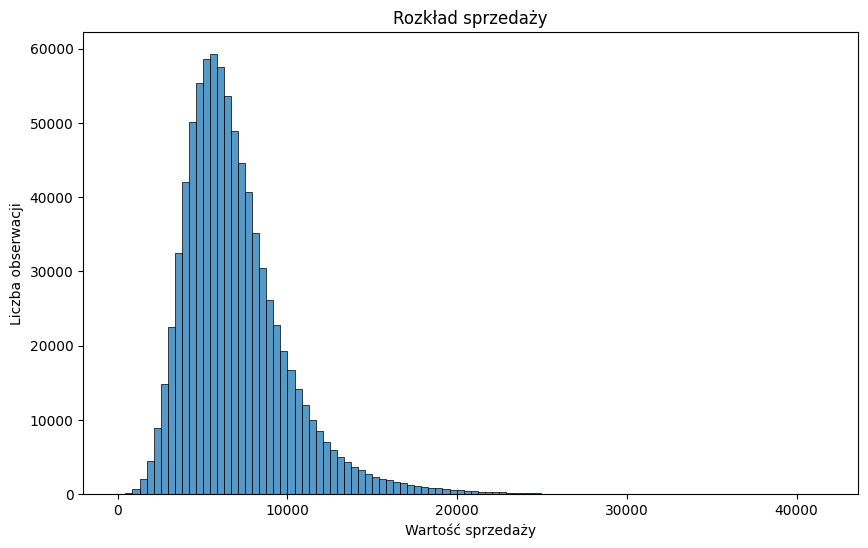

In [36]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['Sales']>0]['Sales'], bins=100, kde=False)
plt.title('Rozkład sprzedaży')
plt.xlabel('Wartość sprzedaży')
plt.ylabel('Liczba obserwacji')
plt.show()

In [13]:
df_train['Date'] = pd.to_datetime(df_train['Date']) 
df_train = df_train.sort_values('Date')

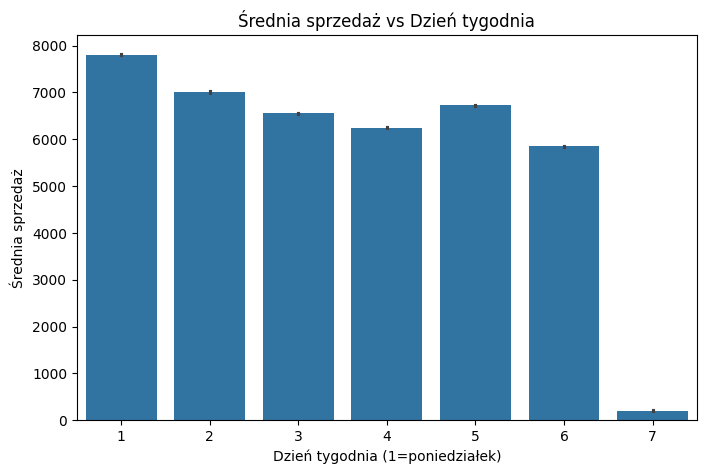

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x='DayOfWeek', y='Sales', data=df_train)
plt.title('Średnia sprzedaż vs Dzień tygodnia')
plt.xlabel('Dzień tygodnia (1=poniedziałek)')
plt.ylabel('Średnia sprzedaż')
plt.show()

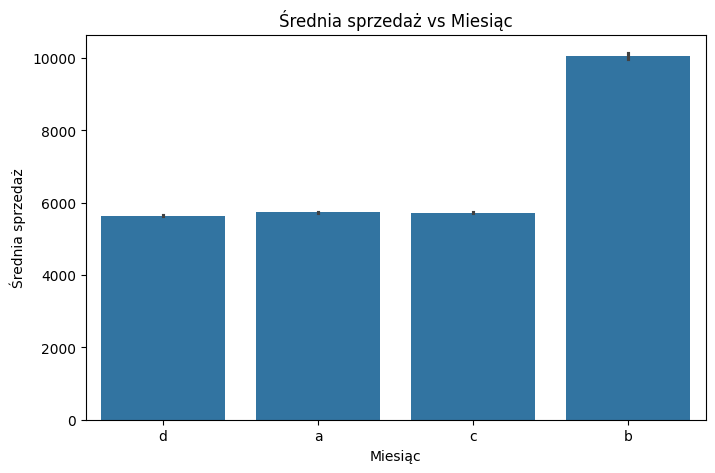

In [78]:
# Średnia sprzedaż w zależności od miesiąca
plt.figure(figsize=(8,5))
sns.barplot(x='StoreType', y='Sales', data=df)
plt.title('Średnia sprzedaż vs Miesiąc')
plt.xlabel('Miesiąc')
plt.ylabel('Średnia sprzedaż')
plt.show()

In [81]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'day_of_week', 'month', 'StoreType',
       'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

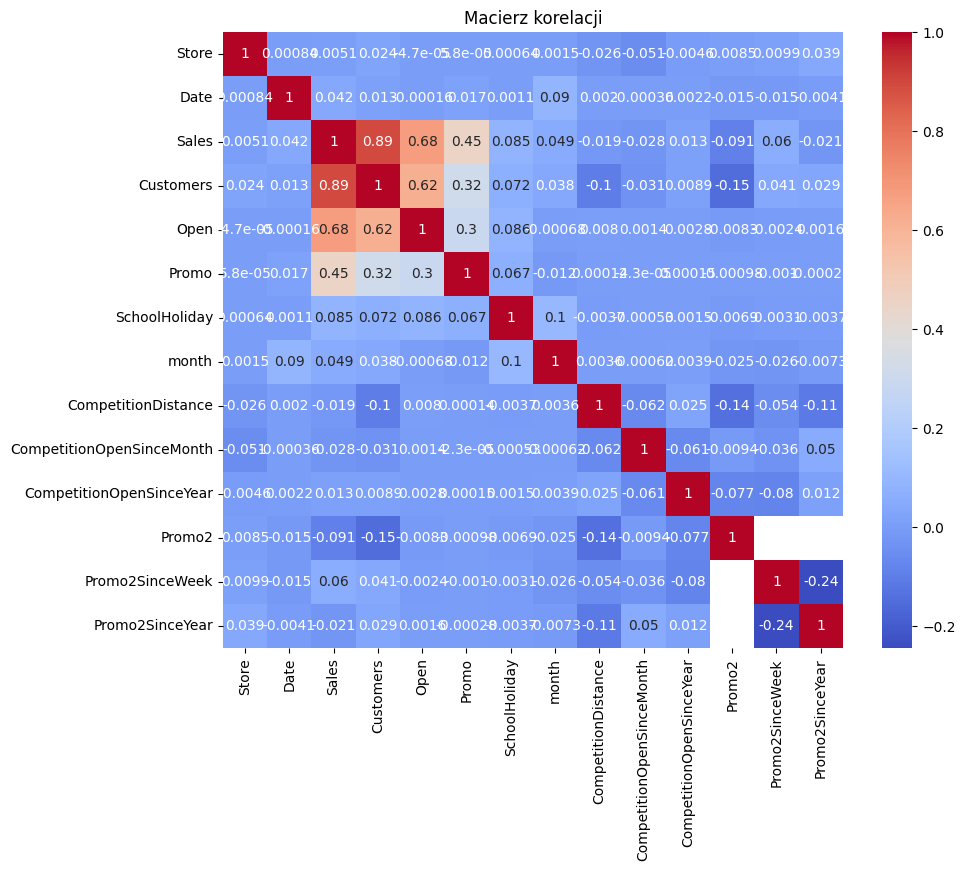

In [88]:
corr = df.drop(['StateHoliday','DayOfWeek','StoreType','Assortment','PromoInterval','day_of_week'], axis=1).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Macierz korelacji')
plt.show()

In [89]:
df.to_csv("../data/preprocessed/sales_store.csv")